In [154]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,OneHotEncoder,RobustScaler,MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LinearRegression,LogisticRegression
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay,classification_report
from sklearn.linear_model import Ridge

import tensorflow as tf
from tensorflow.keras import layers, models, datasets
import matplotlib.pyplot as plt
import numpy as np
import os
import cv2
import random
import keras
from PIL import Image
from sklearn.model_selection import train_test_split

In [155]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("puneet6060/intel-image-classification")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/puneet6060/intel-image-classification


In [156]:
!ls /kaggle/input/datasets/puneet6060/intel-image-classification

seg_pred  seg_test  seg_train


In [157]:
BASE_DIR = path

train_dir = os.path.join(BASE_DIR, 'seg_train','seg_train')

test_dir = os.path.join( BASE_DIR, "seg_test", "seg_test")
pred_dir = os.path.join( BASE_DIR, "seg_pred", "seg_pred")

print(os.listdir(train_dir))
#print(os.listdir(test_dir))

['mountain', 'street', 'buildings', 'sea', 'forest', 'glacier']


In [158]:
train_mountain_dir = os.path.join(train_dir, 'mountain')
train_street_dir = os.path.join(train_dir, 'street')
train_buildings_dir = os.path.join(train_dir, 'buildings')
train_sea_dir = os.path.join(train_dir, 'sea')
train_forest_dir = os.path.join(train_dir, 'forest')
train_glacier_dir = os.path.join(train_dir, 'glacier')

In [159]:
test_mountain_dir = os.path.join(test_dir, 'mountain')
test_street_dir = os.path.join(test_dir, 'street')
test_buildings_dir = os.path.join(test_dir, 'buildings')
test_sea_dir = os.path.join(test_dir, 'sea')
test_forest_dir = os.path.join(test_dir, 'forest')
test_glacier_dir = os.path.join(test_dir, 'glacier')

In [160]:
IMAGE_SIZE = (64, 64)  # 64 * 64 , 224*224 # CONSTANT
BATCH_SIZE = 128

from concurrent.futures import ThreadPoolExecutor

def load_images_and_labels(directory, label):
    image_files = [f for f in os.listdir(directory) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    filepaths = [os.path.join(directory, f) for f in image_files]

    def read_one(filepath):
        image = cv2.imread(filepath)
        image = cv2.resize(image, IMAGE_SIZE)
        return image

    with ThreadPoolExecutor(max_workers=16) as executor:
        images = list(executor.map(read_one, filepaths))

    labels = [label] * len(images)
    return images, labels


In [161]:
print("Loading training mountain images...")
X_train_mountain, y_train_mountain = load_images_and_labels(train_mountain_dir, 0) 
print(f"Loaded {len(X_train_mountain)} training mountain images.")

print("Loading training street images...")
X_train_street, y_train_street = load_images_and_labels(train_street_dir, 1) 
print(f"Loaded {len(X_train_street)} training street images.")

print("Loading training buildings images...")
X_train_buildings, y_train_buildings = load_images_and_labels(train_buildings_dir, 2) 
print(f"Loaded {len(X_train_buildings)} training buildings images.")

print("Loading training sea images...")
X_train_sea, y_train_sea = load_images_and_labels(train_sea_dir, 0) 
print(f"Loaded {len(X_train_sea)} training sea images.")

print("Loading training forest images...")
X_train_forest, y_train_forest = load_images_and_labels(train_forest_dir, 1) 
print(f"Loaded {len(X_train_forest)} training forest images.")

print("Loading training glacier images...")
X_train_glacier, y_train_glacier = load_images_and_labels(train_glacier_dir, 2) 
print(f"Loaded {len(X_train_glacier)} training glacier images.")

Loading training mountain images...
Loaded 2512 training mountain images.
Loading training street images...
Loaded 2382 training street images.
Loading training buildings images...
Loaded 2191 training buildings images.
Loading training sea images...
Loaded 2274 training sea images.
Loading training forest images...
Loaded 2271 training forest images.
Loading training glacier images...
Loaded 2404 training glacier images.


In [162]:
print("Loading training mountain images...")
X_test_mountain, y_test_mountain = load_images_and_labels(test_mountain_dir, 0) 
print(f"Loaded {len(X_test_mountain)} test mountain images.")

print("Loading test street images...")
X_test_street, y_test_street = load_images_and_labels(test_street_dir, 1) 
print(f"Loaded {len(X_test_street)} test street images.")

print("Loading test buildings images...")
X_test_buildings, y_test_buildings = load_images_and_labels(test_buildings_dir, 2) 
print(f"Loaded {len(X_test_buildings)} test buildings images.")

print("Loading test sea images...")
X_test_sea, y_test_sea = load_images_and_labels(test_sea_dir, 0) 
print(f"Loaded {len(X_test_sea)} test sea images.")

print("Loading test forest images...")
X_test_forest, y_test_forest = load_images_and_labels(test_forest_dir, 1) 
print(f"Loaded {len(X_test_forest)} test forest images.")

print("Loading test glacier images...")
X_test_glacier, y_test_glacier = load_images_and_labels(test_glacier_dir, 2) 
print(f"Loaded {len(X_test_glacier)} test glacier images.")

Loading training mountain images...
Loaded 525 test mountain images.
Loading test street images...
Loaded 501 test street images.
Loading test buildings images...
Loaded 437 test buildings images.
Loading test sea images...
Loaded 510 test sea images.
Loading test forest images...
Loaded 474 test forest images.
Loading test glacier images...
Loaded 553 test glacier images.


In [163]:
def shuffle_data(images, labels):
    combined = list(zip(images, labels))
    random.shuffle(combined)
    shuffled_images, shuffled_labels = zip(*combined)
    return np.array(shuffled_images), np.array(shuffled_labels)

In [164]:
X_test = np.array(X_test_mountain + X_test_street + X_test_buildings + X_test_sea+ X_test_forest + X_test_glacier ) 
y_test = np.array(y_test_mountain + y_test_street + y_test_buildings + y_test_sea+ y_test_forest + y_test_glacier )

X_test, y_test = shuffle_data(X_test,y_test) #  train  split with random state

print(f"Total testing images: {len(X_test)}")

Total testing images: 3000


In [165]:
X_pred, y_pred = load_images_and_labels(pred_dir, 0) 
X_pred=np.array(X_pred)
y_predt=np.array(y_pred)
X_pred, y_pred = shuffle_data(X_pred, y_pred) #  train  split with random state

print(f"Total pred images: {len(X_pred)}")

Total pred images: 7301


In [166]:
# Combine and shuffle training data
X_train = np.array(X_train_mountain + X_train_street + X_train_buildings + X_train_sea+ X_train_forest + X_train_glacier ) 
y_train = np.array(y_train_mountain + y_train_street + y_train_buildings + y_train_sea+ y_train_forest + y_train_glacier )


# Shuffle the data consistently
def shuffle_data(images, labels):
    combined = list(zip(images, labels))
    random.shuffle(combined)
    shuffled_images, shuffled_labels = zip(*combined)
    return np.array(shuffled_images), np.array(shuffled_labels)

X_train, y_train = shuffle_data(X_train, y_train) #  train  split with random state

print(f"Total training images: {len(X_train)}")

Total training images: 14034


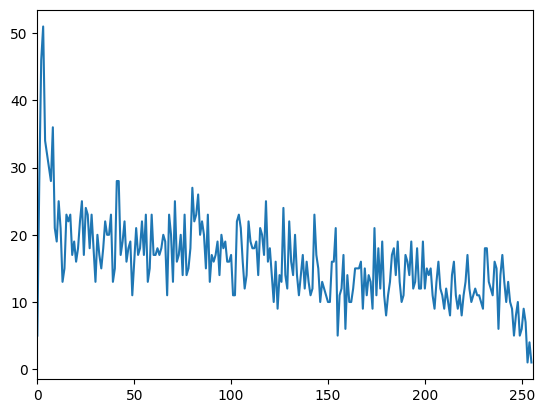

In [167]:
gray = cv2.cvtColor(X_train[0], cv2.COLOR_BGR2GRAY)
hist = cv2.calcHist([gray], [0], None, [256], [0, 256])
plt.plot(hist)
plt.xlim([0, 256])
plt.show()


In [168]:
# image processing
gray_images = np.array([cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) for img in X_train])
clahe = cv2.createCLAHE(
    clipLimit=2.0, tileGridSize=(8, 8)
)
enhanced = clahe.apply(gray)

X_train = X_train.astype('float32') / 255.0 #0 to 1
X_test = X_test.astype('float32') / 255.0 #0 to 1




In [182]:

model = tf.keras.Sequential([
    keras.layers.Input(shape=(64,64,3)),
    
   keras.layers.RandomFlip('horizontal'),
   keras.layers.RandomRotation(0.08),
   keras.layers.RandomZoom(0.10),
   keras.layers.RandomContrast(0.10),
   keras.layers.RandomTranslation(0.05, 0.05),
    
    keras.layers.Conv2D(256, (3,3), strides=1, padding="same", activation="relu"),
    keras.layers.MaxPool2D((2,2)),
    keras.layers.Dropout(0.5),
    keras.layers.Conv2D(256, (3,3), strides=1, activation="relu", use_bias=False),
    keras.layers.BatchNormalization(axis=-1, momentum=0.99, epsilon=1e-3, center=True, scale=True),
    keras.layers.Conv2D(128, (3,3), strides=1, activation="relu"),
    keras.layers.Conv2D(64, (3,3), strides=1, activation="relu"),
    keras.layers.MaxPool2D((2,2)),
    keras.layers.Conv2D(32, (3,3), padding='same', activation="relu"),
    keras.layers.Conv2D(32, (3,3), strides=1, activation="relu"),
    keras.layers.Flatten(),
    keras.layers.Dense(3, activation="softmax"),
])

In [183]:
model.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_5 (RandomFlip)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_5               │ (None, 64, 64, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_5 (RandomZoom)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast_5               │ (None, 64, 64, 3)      │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation_5            │ (None, 64, 64, 3)      │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_66 (Conv2D)              │ (None, 64, 64, 256)    │         7,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_67 (Conv2D)              │ (None, 30, 30, 256)    │       589,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 30, 30, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_68 (Conv2D)              │ (None, 28, 28, 128)    │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_69 (Conv2D)              │ (None, 26, 26, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_70 (Conv2D)              │ (None, 13, 13, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_71 (Conv2D)              │ (None, 11, 11, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_11 (Flatten)            │ (None, 3872)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │        11,619 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,006,179 (3.84 MB)

 Trainable params: 1,005,667 (3.84 MB)

 Non-trainable params: 512 (2.00 KB)

In [186]:
model.compile(
    optimizer="Adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [188]:
Early_stopping=keras.callbacks.EarlyStopping(
    monitor="val_loss",
    min_delta=0,
    patience=5,
    verbose=0,
    mode="auto",
    baseline=None,
    restore_best_weights=True,
    start_from_epoch=5,
)

In [189]:
model.fit(X_train,y_train,batch_size=BATCH_SIZE,epochs=35,validation_split=0.2,callbacks=Early_stopping)

Epoch 1/35


E0000 00:00:1788612786.583493      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/sequential_11_1/dropout_11_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


88/88 ━━━━━━━━━━━━━━━━━━━━ 18s 171ms/step - accuracy: 0.6363 - loss: 0.7747 - val_accuracy: 0.5394 - val_loss: 0.9666
Epoch 2/35
88/88 ━━━━━━━━━━━━━━━━━━━━ 15s 166ms/step - accuracy: 0.7396 - loss: 0.6101 - val_accuracy: 0.7296 - val_loss: 0.7860
Epoch 3/35
88/88 ━━━━━━━━━━━━━━━━━━━━ 15s 167ms/step - accuracy: 0.7571 - loss: 0.5657 - val_accuracy: 0.5743 - val_loss: 0.8738
Epoch 4/35
88/88 ━━━━━━━━━━━━━━━━━━━━ 15s 167ms/step - accuracy: 0.7648 - loss: 0.5465 - val_accuracy: 0.7663 - val_loss: 0.5857
Epoch 5/35
88/88 ━━━━━━━━━━━━━━━━━━━━ 15s 168ms/step - accuracy: 0.7706 - loss: 0.5254 - val_accuracy: 0.7047 - val_loss: 0.6892
Epoch 6/35
88/88 ━━━━━━━━━━━━━━━━━━━━ 15s 171ms/step - accuracy: 0.7810 - loss: 0.5155 - val_accuracy: 0.7353 - val_loss: 0.6234
Epoch 7/35
88/88 ━━━━━━━━━━━━━━━━━━━━ 15s 174ms/step - accuracy: 0.7862 - loss: 0.4995 - val_accuracy: 0.7581 - val_loss: 0.5853
Epoch 8/35
88/88 ━━━━━━━━━━━━━━━━━━━━ 15s 175ms/step - accuracy: 0.7947 - loss: 0.4874 - val_accuracy: 0.780

In [191]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)
y_train_pred = np.argmax(y_train_pred, axis=1)
y_test_pred = np.argmax(y_test_pred, axis=1)

print(classification_report(y_train, y_train_pred))
print(classification_report(y_test, y_test_pred))

439/439 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
              precision    recall  f1-score   support

           0       0.84      0.80      0.82      4786
           1       0.89      0.92      0.90      4653
           2       0.75      0.76      0.75      4595

    accuracy                           0.83     14034
   macro avg       0.83      0.83      0.83     14034
weighted avg       0.83      0.83      0.83     14034

              precision    recall  f1-score   support

           0       0.82      0.77      0.80      1035
           1       0.88      0.91      0.90       975
           2       0.72      0.74      0.73       990

    accuracy                           0.81      3000
   macro avg       0.81      0.81      0.81      3000
weighted avg       0.81      0.81      0.81      3000



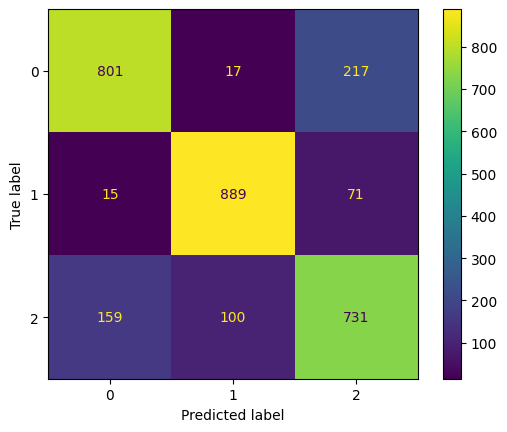

In [193]:
target = [0, 1, 2]
cm=confusion_matrix(y_test,y_test_pred)
C_display=ConfusionMatrixDisplay(cm,display_labels=target)
C_display.plot()
plt.show()